In [48]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import torch.optim as optim
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
scaler_X = MinMaxScaler()
dfs = pd.read_csv("../data/features.csv", index_col="Time_[s]")
targets = pd.read_csv("../data/targets.csv", index_col=False)
# df = dfs[dfs["Experiment_ID"]==2].drop(columns=["Experiment_ID"])
# target = targets[targets["Experiment_ID"]==2].iloc[:, 2:]
col = "Angle[degree]ORDistance[mm]"
# bend_columns = [col for col in dfs.columns if 'BEND' in col]
# bend_columns.insert(0,'Experiment_ID')
# dfs = dfs.loc[:, bend_columns]

scaler = MinMaxScaler(feature_range=(0, 1))
targets[col] = scaler.fit_transform(targets[[col]])
dfs

,Experiment_ID,MACHINE_BEND-DIE_LATERAL_Max_Torque_[%],MACHINE_BEND-DIE_ROTATING_Max_Torque_[%],MACHINE_BEND-DIE_VERTICAL_Max_Torque_[%],MACHINE_CLAMP-DIE_LATERAL_Max_Torque_[%],MACHINE_COLLET_AXIAL_Max_Torque_[%],MACHINE_COLLET_ROTATING_Max_Torque_[%],MACHINE_MANDREL_AXIAL_Max_Torque_[%],MACHINE_PRESSURE-DIE_LATERAL_Max_Torque_[%],MACHINE_PRESSURE-DIE_LEFT_AXIAL_Max_Torque_[%],BEND-DIE_LATERAL_Movement_[mm],BEND-DIE_ROTATING_Angle_[°],BEND-DIE_VERTICAL_Movement_[mm],CLAMP-DIE_LATERAL_Movement_[mm],COLLET_AXIAL_Movement_[mm],MANDREL_AXIAL_Movement_[mm],PRESSURE-DIE_AXIAL_Movement_[mm],PRESSURE-DIE_LATERAL_Movement_[mm]
Time_[s],,,,,,,,,,,,,,,,,,
0.00,2,0.135068,0.817045,0.293651,0.436154,0.397692,0.107143,0.985937,0.757580,0.59375,0.999967,1.000000,0.456468,0.570124,0.000005,0.900879,0.000373,0.999849
0.05,2,0.135068,0.817045,0.285714,0.436154,0.397822,0.107143,0.985937,0.750271,0.59375,0.999967,1.000000,0.456468,0.570124,0.000004,0.900879,0.000373,0.999842
0.10,2,0.135068,0.817045,0.293651,0.436154,0.398065,0.107143,0.984375,0.698300,0.59375,0.999967,1.000000,0.456468,0.570124,0.000004,0.900879,0.000373,0.999540
0.15,2,0.136307,0.817045,0.293651,0.436154,0.397887,0.107143,0.985937,0.585460,0.62500,0.999967,1.000000,0.456468,0.570124,0.000005,0.900879,0.000373,0.998401
0.20,2,0.135068,0.817045,0.285714,0.436154,0.397741,0.107143,0.984375,0.476972,0.65625,0.999967,1.000000,0.456468,0.570124,0.000002,0.900879,0.000373,0.997003
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86.30,314,0.074349,0.875032,0.285714,0.419720,0.414831,0.785714,0.926562,0.793701,0.43750,0.000007,0.997979,0.456468,0.000004,0.984199,0.094463,0.000373,0.999849
86.35,314,0.074349,0.872084,0.293651,0.419720,0.415124,0.785714,0.928125,0.793552,0.43750,0.000007,0.998670,0.456468,0.000004,0.984199,0.094463,0.000373,0.999849
86.40,314,0.074349,0.874473,0.285714,0.419720,0.415188,0.785714,0.926562,0.793404,0.43750,0.000007,0.999223,0.456468,0.000004,0.984199,0.094463,0.000373,0.999849


In [49]:
groups_y = []
max_len_y = targets.groupby("Experiment_ID").size().max()
num_target_features = targets.shape[1] - 1  # exclude Experiment_ID

for exp_id, group in targets.groupby("Experiment_ID"):
    values = group.drop(columns=["Experiment_ID"]).values  # (len_group, num_target_features)
    
    # Pad with NaN
    padded = np.full((max_len_y, num_target_features), np.nan)
    padded[:values.shape[0], :] = values
    groups_y.append(padded)

# Final y: (num_experiments, max_len, num_target_features)
y = np.array(groups_y, dtype=float)

# Replace NaN with 0
Y = np.nan_to_num(y, nan=0.0)



groups = []
max_len = dfs.groupby("Experiment_ID").size().max()  # longest experiment
num_features = dfs.shape[1] - 1  # exclude Experiment_ID

for exp_id, group in dfs.groupby("Experiment_ID"):
    features = group.drop(columns=["Experiment_ID"]).values
    
    # Pad with NaN (or zeros) to match max_len2,
    padded = np.full((max_len, num_features), np.nan)  
    padded[:features.shape[0], :] = features
    groups.append(padded)


X = np.array(groups, dtype=float)
X = np.nan_to_num(X, nan=0.0)[:,:,:]
Y = np.nan_to_num(y, nan=0.0)[:,:,1:-1]
print("Shape:", X.shape, Y.shape)  

Shape: (100, 1743, 17) (100, 47, 4)


In [50]:
from sklearn.ensemble import RandomForestRegressor

# X: (num_samples, seq_len, num_features)
# Y: (num_samples, num_angles, 3)
num_samples, seq_len, num_features = X.shape
num_angles = Y.shape[1]
output_size = Y.shape[2]

# Prepare training data
X_rf = []
Y_rf = []

for sample_idx in range(num_samples):
    for angle_idx in range(num_angles):
        x_seq = X[sample_idx].flatten()
        degree = angle_idx / (num_angles - 1)
        x_with_angle = np.append(x_seq, degree)
        X_rf.append(x_with_angle)
        Y_rf.append(Y[sample_idx, angle_idx])

X_rf = np.array(X_rf)
Y_rf = np.array(Y_rf)

In [51]:
from sklearn.ensemble import RandomForestRegressor
import joblib

rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    max_features='sqrt',
    n_jobs=-1,
    oob_score=True,
    random_state=42,
    verbose=0
)

rf.fit(X_rf, Y_rf)
joblib.dump(rf, "rf.joblib")

['rf.joblib']

OOB Score (~0.78)

Out-of-bag (OOB) is like an internal cross-validation for Random Forests.

0.78 means the model explains roughly 78% of the variance on unseen samples from the training data.

This is a good sign that your model is not severely overfitting, since it’s close to your validation R².

2️⃣ Validation R² (~0.71)

This is the actual score on a held-out set.

0.71 means the model explains ~71% of the variance for truly unseen samples.

There’s a slight drop from OOB, which is normal. A drop of ~0.05–0.1 is acceptable.

3️⃣ Interpretation

The fact that OOB > Validation R² by a moderate margin indicates the model is generalizing fairly well.

If OOB >> Validation R², that would indicate overfitting.

If OOB << Validation R², that would suggest the OOB estimate might be unstable (rare).

In [59]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider, fixed

def plot_window_for_angle(sample_idx, angle_idx, X, Y, rf, num_angles, num_features, patch_size, stride):
    _, seq_len, _ = X.shape
    num_patches = (seq_len - patch_size) // stride + 1

    # Flatten input and append angle
    x_input = X[sample_idx].flatten()
    degree = angle_idx / (num_angles - 1)
    x_with_angle = np.append(x_input, degree)
    y_true = Y[sample_idx, angle_idx]

    # Compute permutation-based errors per window
    window_errors = []
    for w in range(num_patches):
        start_w = w * stride * num_features
        end_w = start_w + patch_size * num_features

        if np.all(x_with_angle[start_w:end_w] == 0):
            window_errors.append(np.nan)
            continue

        x_active = np.zeros_like(x_with_angle)
        x_active[start_w:end_w] = x_with_angle[start_w:end_w]

        y_hat = rf.predict(x_active.reshape(1, -1))[0]
        error = np.linalg.norm(y_true - y_hat)
        window_errors.append(error)

    window_errors = np.array(window_errors)
    if np.all(np.isnan(window_errors)):
        most_accurate_window = None
    else:
        most_accurate_window = np.nanargmin(window_errors)

    # ---------- Combined Figure ----------
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

    # Top subplot: features and error curve
    for f in range(num_features):
        ax1.plot(X[sample_idx, :, f], label=f'Feature {f}')

    # if most_accurate_window is not None:
    #     start = most_accurate_window * stride
    #     end = start + patch_size
    #     if end > seq_len:
    #         end = seq_len
    #     ax1.axvspan(start, end, color='green', alpha=0.3, label='Most Accurate Window')

    error_curve = np.full(seq_len, np.nan)
    for w, err in enumerate(window_errors):
        start = w * stride
        end = start + patch_size
        if end > seq_len:
            end = seq_len
        error_curve[start:end] = err

    ax1_twin = ax1.twinx()
    ax1_twin.plot(range(seq_len), error_curve, color='black', linestyle='--', linewidth=2, label='Prediction Error')
    ax1.set_xlabel("Timestep")
    ax1.set_ylabel("Feature value")
    ax1_twin.set_ylabel("Error (L2 norm)")
    ax1.set_title(f"Sample {sample_idx}, Angle {angle_idx} - Most Accurate Window & Error Curve")
    ax1.legend(loc='upper left')
    ax1_twin.legend(loc='upper right')

    # Bottom subplot: true vs predicted
    y_pred = rf.predict(x_with_angle.reshape(1, -1))[0]
    for c in range(Y.shape[2]):
        ax2.bar(c-0.2, y_true[c], width=0.4, label=f'True Channel {c}' if c==0 else "")
        ax2.bar(c+0.2, y_pred[c], width=0.4, label=f'Pred Channel {c}' if c==0 else "")
    ax2.set_xticks(range(Y.shape[2]))
    ax2.set_ylabel("Target value")
    ax2.set_title(f"True vs Predicted for Sample {sample_idx}, Angle {angle_idx}")
    ax2.legend()

    plt.tight_layout()
    plt.show()



# ---------- Interactive widget ----------
interact(
    plot_window_for_angle,
    sample_idx=IntSlider(min=0, max=X.shape[0]-1, step=1, value=0),
    angle_idx=IntSlider(min=0, max=num_angles-2, step=1, value=0),
    X=fixed(X),
    Y=fixed(Y),
    rf=fixed(rf),
    num_angles=fixed(num_angles),
    num_features=fixed(num_features),
    patch_size=IntSlider(min=50, max=500, step=50, value=200),
    stride=IntSlider(min=10, max=200, step=10, value=200)
)


interactive(children=(IntSlider(value=0, description='sample_idx', max=99), IntSlider(value=0, description='an…

<function __main__.plot_window_for_angle(sample_idx, angle_idx, X, Y, rf, num_angles, num_features, patch_size, stride)>

# Ridge

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from ipywidgets import interact, IntSlider, fixed

def window_model_importance(X, Y, sample_idx, angle_idx, patch_size, stride, alpha=1.0):
    """
    Model-based window feature importance using Ridge regression as surrogate.
    X: [samples, seq_len, features]
    Y: [samples, angles, channels]
    """
    seq_len, num_features = X.shape[1], X.shape[2]
    num_patches = (seq_len - patch_size) // stride + 1

    # Flatten target (single channel for importance)
    y_target = Y[sample_idx, angle_idx, 0]

    importance_matrix = []

    for w in range(num_patches):
        start = w * stride
        end = start + patch_size
        if end > seq_len:
            break

        X_window = X[sample_idx, start:end, :]  # shape: [window, features]
        y_window = np.full((end-start,), y_target)  # constant target per window

        # Train a local surrogate model
        model = Ridge(alpha=alpha)
        try:
            model.fit(X_window, y_window)
            imp = np.abs(model.coef_)
        except:
            imp = np.zeros(num_features)

        importance_matrix.append(imp)

    return np.array(importance_matrix).T  # shape: features x windows


def plot_window_model_importance(sample_idx, angle_idx, X, Y, num_features, patch_size, stride, alpha=1.0):
    model_importance = window_model_importance(X, Y, sample_idx, angle_idx, patch_size, stride, alpha)

    fig, ax = plt.subplots(figsize=(12, 6))
    im = ax.imshow(model_importance, aspect="auto", origin="lower")
    ax.set_title(f"Model-Based (Ridge) Window Feature Importance (Sample {sample_idx}, Angle {angle_idx})")
    ax.set_xlabel("Window Index")
    ax.set_ylabel("Feature Index")
    fig.colorbar(im, ax=ax, label="Coefficient Magnitude (|weight|)")
    plt.show()


# ---------- Interactive widget ----------
interact(
    plot_window_model_importance,
    sample_idx=IntSlider(min=0, max=X.shape[0]-1, step=1, value=0),
    angle_idx=IntSlider(min=0, max=Y.shape[1]-1, step=1, value=0),
    X=fixed(X),
    Y=fixed(Y),
    num_features=fixed(num_features),
    patch_size=IntSlider(min=20, max=200, step=20, value=50),
    stride=IntSlider(min=5, max=100, step=5, value=20),
    alpha=IntSlider(min=1, max=100, step=5, value=10)
)


interactive(children=(IntSlider(value=0, description='sample_idx', max=99), IntSlider(value=0, description='an…

<function __main__.plot_window_model_importance(sample_idx, angle_idx, X, Y, num_features, patch_size, stride, alpha=1.0)>

# Feature Permutation

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider, fixed

def plot_window_for_angle(sample_idx, angle_idx, X, Y, rf, num_angles, num_features, patch_size, stride):
    _, seq_len, _ = X.shape
    num_patches = (seq_len - patch_size) // stride + 1

    # Flatten input and append angle
    x_input = X[sample_idx].flatten()
    degree = angle_idx / (num_angles - 1)
    x_with_angle = np.append(x_input, degree)
    y_true = Y[sample_idx, angle_idx]
        
    window_errors = [] 
    for w in range(num_patches): 
        start_w = w * stride * num_features 
        end_w = start_w + patch_size * num_features 

        if np.all(x_with_angle[start_w:end_w] == 0):
            window_errors.append(np.nan)
            continue

        # Copy input
        x_perm = x_with_angle.copy() 

        # Permute THIS window only
        x_perm[start_w:end_w] = np.random.permutation(x_perm[start_w:end_w])

        # Predict
        y_hat = rf.predict(x_perm.reshape(1, -1))[0] 
        error = np.linalg.norm(y_true - y_hat) 

        # Append ONE error per window
        window_errors.append(error)

    window_errors = np.array(window_errors)
    if np.all(np.isnan(window_errors)):
        most_accurate_window = None
    else:
        most_accurate_window = np.nanargmin(window_errors)

    # ---------- Combined Figure ----------
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

    # Top subplot: features and error curve
    for f in range(num_features):
        ax1.plot(X[sample_idx, :, f], label=f'Feature {f}')

    # if most_accurate_window is not None:
    #     start = most_accurate_window * stride
    #     end = start + patch_size
    #     if end > seq_len:
    #         end = seq_len
    #     ax1.axvspan(start, end, color='green', alpha=0.3, label='Most Accurate Window')

    error_curve = np.full(seq_len, np.nan)
    for w, err in enumerate(window_errors):
        start = w * stride
        end = start + patch_size
        if end > seq_len:
            end = seq_len
        error_curve[start:end] = err

    ax1_twin = ax1.twinx()
    ax1_twin.plot(range(seq_len), error_curve, color='black', linestyle='--', linewidth=2, label='Prediction Error')
    ax1.set_xlabel("Timestep")
    ax1.set_ylabel("Feature value")
    ax1_twin.set_ylabel("Error (L2 norm)")
    ax1.set_title(f"Sample {sample_idx}, Angle {angle_idx} - Most Accurate Window & Error Curve")
    ax1.legend(loc='upper left')
    ax1_twin.legend(loc='upper right')

    # Bottom subplot: true vs predicted
    y_pred = rf.predict(x_with_angle.reshape(1, -1))[0]
    for c in range(Y.shape[2]):
        ax2.bar(c-0.2, y_true[c], width=0.4, label=f'True Channel {c}' if c==0 else "")
        ax2.bar(c+0.2, y_pred[c], width=0.4, label=f'Pred Channel {c}' if c==0 else "")
    ax2.set_xticks(range(Y.shape[2]))
    ax2.set_ylabel("Target value")
    ax2.set_title(f"True vs Predicted for Sample {sample_idx}, Angle {angle_idx}")
    ax2.legend()

    plt.tight_layout()
    plt.show()



# ---------- Interactive widget ----------
interact(
    plot_window_for_angle,
    sample_idx=IntSlider(min=0, max=X.shape[0]-1, step=1, value=0),
    angle_idx=IntSlider(min=0, max=num_angles-2, step=1, value=0),
    X=fixed(X),
    Y=fixed(Y),
    rf=fixed(rf),
    num_angles=fixed(num_angles),
    num_features=fixed(num_features),
    patch_size=IntSlider(min=50, max=500, step=50, value=200),
    stride=IntSlider(min=10, max=200, step=10, value=200)
)


interactive(children=(IntSlider(value=0, description='sample_idx', max=99), IntSlider(value=0, description='an…

<function __main__.plot_window_for_angle(sample_idx, angle_idx, X, Y, rf, num_angles, num_features, patch_size, stride)>

# Occlusion

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider, fixed

# ----------------- Window Occlusion Importance -----------------
def window_occlusion_importance(X, Y, sample_idx, angle_idx, rf,
                                patch_size, stride, num_features):
    seq_len = X.shape[1]
    num_windows = (seq_len - patch_size) // stride + 1

    # Full input with angle
    x_input = X[sample_idx].flatten()
    degree = angle_idx / (Y.shape[1] - 1)
    x_with_angle = np.append(x_input, degree).reshape(1, -1)

    # Original prediction
    y_pred_full = rf.predict(x_with_angle)[0]

    occlusion_errors = []
    for w in range(num_windows):
        start_w = w * stride * num_features
        end_w   = start_w + patch_size * num_features

        # Skip if window already all zeros
        if np.all(x_with_angle[0, start_w:end_w] == 0):
            occlusion_errors.append(np.nan)
            continue

        # Copy input and mask window
        x_masked = x_with_angle.copy()
        x_masked[0, start_w:end_w] = 0

        # Predict
        y_pred_masked = rf.predict(x_masked)[0]

        # Error difference
        diff = np.linalg.norm(y_pred_full - y_pred_masked)
        occlusion_errors.append(diff)

    return np.array(occlusion_errors)


# ----------------- Plot Function -----------------
def plot_occlusion_importance_with_features(sample_idx, angle_idx, X, Y, rf, num_features, patch_size, stride):
    importance_curve = window_occlusion_importance(X, Y, sample_idx, angle_idx, rf,
                                                   patch_size, stride, num_features)

    seq_len = X.shape[1]

    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Plot original features
    for f in range(num_features):
        ax1.plot(X[sample_idx, :, f], label=f'Feature {f}')

    # Plot occlusion importance as dashed line
    error_curve = np.full(seq_len, np.nan)
    num_windows = len(importance_curve)
    for w, err in enumerate(importance_curve):
        start = w * stride
        end = start + patch_size
        if end > seq_len:
            end = seq_len
        error_curve[start:end] = err

    ax2 = ax1.twinx()
    ax2.plot(range(seq_len), error_curve, color='black', linestyle='--', linewidth=2, label='Occlusion Error')

    ax1.set_xlabel("Timestep")
    ax1.set_ylabel("Feature Value")
    ax2.set_ylabel("Prediction Change (L2 Norm)")
    ax1.set_title(f"Sample {sample_idx}, Angle {angle_idx} - Features & Window Occlusion")
    ax1.legend(loc='upper left')
    ax2.legend(loc='upper right')

    plt.tight_layout()
    plt.show()


# ----------------- Interactive Widget -----------------
interact(
    plot_occlusion_importance_with_features,
    sample_idx=IntSlider(min=0, max=X.shape[0]-1, step=1, value=0),
    angle_idx=IntSlider(min=0, max=Y.shape[1]-1, step=1, value=0),
    X=fixed(X),
    Y=fixed(Y),
    rf=fixed(rf),
    num_features=fixed(num_features),
    patch_size=IntSlider(min=20, max=200, step=20, value=200),
    stride=IntSlider(min=5, max=100, step=5, value=200)
)


interactive(children=(IntSlider(value=0, description='sample_idx', max=99), IntSlider(value=0, description='an…

<function __main__.plot_occlusion_importance_with_features(sample_idx, angle_idx, X, Y, rf, num_features, patch_size, stride)>

In [ ]:
import numpy as np
import shap

def window_shap_importance(X, Y, sample_idx, angle_idx, rf,
                           patch_size, stride, num_features):
    seq_len = X.shape[1]
    num_windows = (seq_len - patch_size) // stride + 1

    # Full input with angle
    x_input = X[sample_idx].flatten()
    degree = angle_idx / (Y.shape[1] - 1)
    x_with_angle = np.append(x_input, degree).reshape(1, -1)

    # Use SHAP to explain prediction
    explainer = shap.TreeExplainer(rf)  # or KernelExplainer if not a tree model
    shap_values = explainer.shap_values(x_with_angle)[0]  # shape: (num_features * seq_len + 1,)

    # Drop the last feature if it's the added angle (unless you want to include it in windows)
    shap_feat_values = shap_values[:-1]

    importance_scores = []
    for w in range(num_windows):
        start_w = w * stride * num_features
        end_w   = start_w + patch_size * num_features

        # Skip if window already all zeros in input
        if np.all(x_with_angle[0, start_w:end_w] == 0):
            importance_scores.append(np.nan)
            continue

        # Aggregate SHAP values in this window (e.g., sum absolute values)
        window_importance = np.sum(np.abs(shap_feat_values[start_w:end_w]))
        importance_scores.append(window_importance)

    return np.array(importance_scores)
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider, fixed

def plot_shap_importance(sample_idx, angle_idx, X, Y, rf, num_features, patch_size, stride):
    seq_len = X.shape[1]

    # ---------- Combined Figure ----------
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

    # Top subplot: features and error curve
    for f in range(num_features):
        ax1.plot(X[sample_idx, :, f], label=f'Feature {f}')

    error_curve = window_shap_importance(
        X, Y, sample_idx, angle_idx, rf,
        patch_size, stride, num_features
    )

    # Create array of window center positions in the sequence
    num_windows = len(error_curve)
    window_centers = np.array([w * stride + patch_size // 2 for w in range(num_windows)])

    ax1_twin = ax1.twinx()
    ax1_twin.plot(window_centers, error_curve, color='black', linestyle='--', linewidth=2, label='Prediction Error')
    ax1.set_xlabel("Timestep")
    ax1.set_ylabel("Feature value")
    ax1_twin.set_ylabel("Error (L2 norm)")
    ax1.set_title(f"Sample {sample_idx}, Angle {angle_idx} - Most Accurate Window & Error Curve")
    ax1.legend(loc='upper left')
    ax1_twin.legend(loc='upper right')

    # Bottom subplot: true vs predicted
    x_input = X[sample_idx].flatten()
    degree = angle_idx / (Y.shape[1] - 1)
    x_with_angle = np.append(x_input, degree).reshape(1, -1)
    y_true = Y[sample_idx, angle_idx, :]

    y_pred = rf.predict(x_with_angle.reshape(1, -1))[0]
    for c in range(Y.shape[2]):
        ax2.bar(c-0.2, y_true[c], width=0.4, label=f'True Channel {c}' if c == 0 else "")
        ax2.bar(c+0.2, y_pred[c], width=0.4, label=f'Pred Channel {c}' if c == 0 else "")
    ax2.set_xticks(range(Y.shape[2]))
    ax2.set_ylabel("Target value")
    ax2.set_title(f"True vs Predicted for Sample {sample_idx}, Angle {angle_idx}")
    ax2.legend()

    plt.tight_layout()
    plt.show()



# ---------- Interactive widget ----------
interact(
    plot_shap_importance,
    sample_idx=IntSlider(min=0, max=X.shape[0]-1, step=1, value=0),
    angle_idx=IntSlider(min=0, max=Y.shape[1]-1, step=1, value=0),
    X=fixed(X),
    Y=fixed(Y),
    rf=fixed(rf),
    num_features=fixed(num_features),
    patch_size=IntSlider(min=20, max=200, step=20, value=50),
    stride=IntSlider(min=5, max=100, step=5, value=20)
)



interactive(children=(IntSlider(value=0, description='sample_idx', max=99), IntSlider(value=0, description='an…

<function __main__.plot_shap_importance(sample_idx, angle_idx, X, Y, rf, num_features, patch_size, stride)>

# Noise importance

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider, fixed

def window_noise_importance(X, Y, sample_idx, angle_idx, rf,
                            patch_size, stride, num_features, noise_std=0.5, n_repeats=5):
    seq_len = X.shape[1]
    num_windows = (seq_len - patch_size) // stride + 1

    # Full input with angle
    x_input = X[sample_idx].flatten()
    degree = angle_idx / (Y.shape[1] - 1)
    x_with_angle = np.append(x_input, degree).reshape(1, -1)

    # Reference prediction
    y_pred_full = rf.predict(x_with_angle)[0]

    importance_scores = []
    for w in range(num_windows):
        start_w = w * stride * num_features
        end_w   = start_w + patch_size * num_features

        # 🔍 Skip if window is already all zeros
        if np.all(x_with_angle[0, start_w:end_w] == 0):
            importance_scores.append(np.nan)
            continue

        diffs = []
        for _ in range(n_repeats):  # repeat for robustness
            x_noisy = x_with_angle.copy()

            # Add Gaussian noise to this entire window
            noise = np.random.normal(0, noise_std, size=(end_w - start_w,))
            x_noisy[0, start_w:end_w] += noise

            # Predict with noisy input
            y_pred_noisy = rf.predict(x_noisy)[0]
            diff = np.linalg.norm(y_pred_full - y_pred_noisy)
            diffs.append(diff)

        # Average importance across noise repetitions
        importance_scores.append(np.mean(diffs))

    return np.array(importance_scores)



def plot_noise_importance(sample_idx, angle_idx, X, Y, rf, num_features, patch_size, stride):   
    seq_len = X.shape[1]

    # ---------- Combined Figure ----------
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

    # Top subplot: features and error curve
    for f in range(num_features):
        ax1.plot(X[sample_idx, :, f], label=f'Feature {f}')

    error_curve = window_noise_importance(X, Y, sample_idx, angle_idx, rf,
                                               patch_size, stride, num_features,
                                               noise_std=0.3, n_repeats=10)

    # Create array of window center positions in the sequence
    num_windows = len(error_curve)
    window_centers = np.array([w * stride + patch_size // 2 for w in range(num_windows)])

    ax1_twin = ax1.twinx()
    ax1_twin.plot(window_centers, error_curve, color='black', linestyle='--', linewidth=2, label='Prediction Error')
    ax1.set_xlabel("Timestep")
    ax1.set_ylabel("Feature value")
    ax1_twin.set_ylabel("Error (L2 norm)")
    ax1.set_title(f"Sample {sample_idx}, Angle {angle_idx} - Most Accurate Window & Error Curve")
    ax1.legend(loc='upper left')
    ax1_twin.legend(loc='upper right')

    # Bottom subplot: true vs predicted
    x_input = X[sample_idx].flatten()
    degree = angle_idx / (Y.shape[1] - 1)
    x_with_angle = np.append(x_input, degree).reshape(1, -1)
    y_true = Y[sample_idx, angle_idx, :]

    y_pred = rf.predict(x_with_angle.reshape(1, -1))[0]
    for c in range(Y.shape[2]):
        ax2.bar(c-0.2, y_true[c], width=0.4, label=f'True Channel {c}' if c == 0 else "")
        ax2.bar(c+0.2, y_pred[c], width=0.4, label=f'Pred Channel {c}' if c == 0 else "")
    ax2.set_xticks(range(Y.shape[2]))
    ax2.set_ylabel("Target value")
    ax2.set_title(f"True vs Predicted for Sample {sample_idx}, Angle {angle_idx}")
    ax2.legend()

    plt.tight_layout()
    plt.show()


# ---------- Interactive widget ----------
interact(
    plot_noise_importance,
    sample_idx=IntSlider(min=0, max=X.shape[0]-1, step=1, value=0),
    angle_idx=IntSlider(min=0, max=Y.shape[1]-1, step=1, value=0),
    X=fixed(X),
    Y=fixed(Y),
    rf=fixed(rf),
    num_features=fixed(num_features),
    patch_size=IntSlider(min=20, max=200, step=20, value=50),
    stride=IntSlider(min=5, max=100, step=5, value=20)
)


interactive(children=(IntSlider(value=0, description='sample_idx', max=99), IntSlider(value=0, description='an…

<function __main__.plot_noise_importance(sample_idx, angle_idx, X, Y, rf, num_features, patch_size, stride)>

Comparing predictions for sample 50:
Angle  0: True=[0.         0.36111677 0.69118349 0.27649826], Pred=[0.01388277 0.35191984 0.66486399 0.30070867]
Angle  1: True=[0.02203614 0.34662522 0.65335099 0.3109318 ], Pred=[0.02379903 0.34539865 0.64783937 0.31620376]
Angle  2: True=[0.04407228 0.33194981 0.60898434 0.35198226], Pred=[0.04958131 0.32798162 0.59434754 0.36577729]
Angle  3: True=[0.06610842 0.31616954 0.55410445 0.40344548], Pred=[0.06368444 0.31812924 0.56017495 0.39781477]
Angle  4: True=[0.08814456 0.30040449 0.49438228 0.45985608], Pred=[0.09409431 0.29931345 0.48844426 0.46560245]
Angle  5: True=[0.1101807  0.29240916 0.45865753 0.4940144 ], Pred=[0.10797708 0.29417864 0.46604572 0.48698366]
Angle  6: True=[0.13221684 0.29055424 0.44873101 0.50361158], Pred=[0.13397973 0.29248346 0.45136133 0.5014838 ]
Angle  7: True=[0.15425297 0.29786392 0.45319747 0.50116356], Pred=[0.14587924 0.2959144  0.45318203 0.50061622]
Angle  8: True=[0.17628911 0.30573333 0.4622038  0.49424294

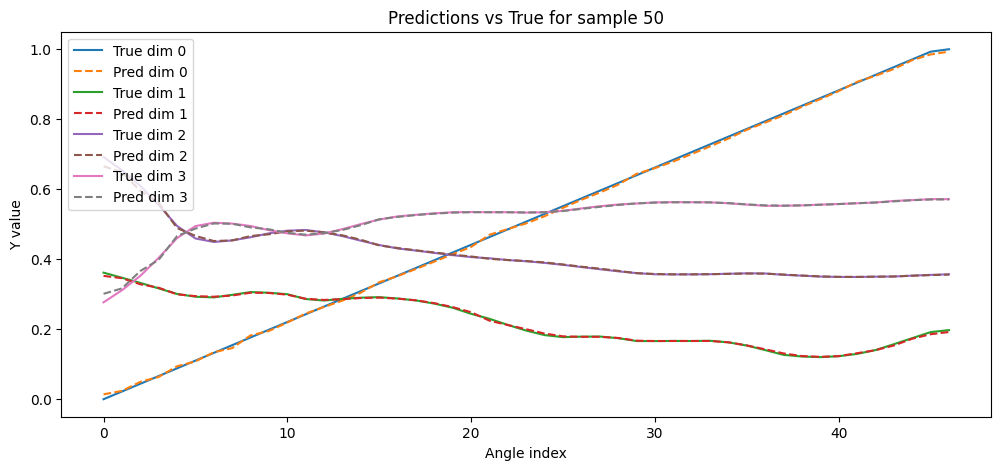

In [38]:
# ---------- Compare predictions for a sample ----------
sample_idx = 50
y_true = Y[sample_idx]  # Shape: (num_angles, 3)
y_pred = []

for angle_idx in range(num_angles):
    x_seq = X[sample_idx].flatten()
    degree = angle_idx / (num_angles - 1)
    x_with_angle = np.append(x_seq, degree)
    y_hat = rf.predict(x_with_angle.reshape(1, -1))
    y_pred.append(y_hat.flatten())

y_pred = np.array(y_pred)  # Shape: (num_angles, 3)

# ---------- Print comparison ----------
print(f"Comparing predictions for sample {sample_idx}:")
for angle_idx in range(num_angles):
    print(f"Angle {angle_idx:2d}: True={y_true[angle_idx]}, Pred={y_pred[angle_idx]}")

# ---------- Optional: plot comparison ----------
plt.figure(figsize=(12, 5))
for dim in range(output_size):
    plt.plot(range(num_angles), y_true[:, dim], label=f'True dim {dim}')
    plt.plot(range(num_angles), y_pred[:, dim], '--', label=f'Pred dim {dim}')
plt.xlabel('Angle index')
plt.ylabel('Y value')
plt.title(f'Predictions vs True for sample {sample_idx}')
plt.legend()
plt.show()